<a href="https://colab.research.google.com/github/Drax1045/MM26ML03-TriageAI/blob/main/Syntax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving train_ml03.csv to train_ml03.csv
Saving test_pred_ml03.csv to test_pred_ml03.csv


In [ ]:
import pandas as pd

train = pd.read_csv("train_ml03.csv")
test = pd.read_csv("test_pred_ml03.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

display(train.head())

Train shape: (664, 39)
Test shape: (112, 38)


,subject_id,gender,race,arrival_transport,temperature,heartrate,resprate,o2sat,sbp,dbp,...,vs_sbp_max,vs_sbp_mean,vs_o2sat_min,vs_o2sat_max,vs_o2sat_mean,vs_temperature_max,n_vitalsign_readings,n_diagnoses,n_home_meds,start_category
0,90000355,F,UNKNOWN,AMBULANCE,97.9,112.0,28.0,89.0,93.0,46.0,...,89.0,85.5,86.0,88.0,87.0,97.7,2,3,6,YELLOW
1,90000004,F,UNABLE TO OBTAIN,AMBULANCE,97.0,NaN,0.0,57.0,NaN,NaN,...,45.0,45.0,NaN,NaN,NaN,96.5,2,2,7,BLACK
2,90000021,M,HISPANIC/LATINO - CUBAN,AMBULANCE,94.1,0.0,0.0,NaN,NaN,NaN,...,24.0,24.0,NaN,NaN,NaN,96.0,3,1,6,BLACK
3,90000176,F,UNKNOWN,AMBULANCE,NaN,NaN,NaN,NaN,NaN,NaN,...,26.0,26.0,10.0,10.0,10.0,96.7,3,1,10,BLACK
4,90000200,M,WHITE,AMBULANCE,94.5,0.0,0.0,27.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,94.8,1,2,9,BLACK


In [ ]:
TARGET = "start_category"

print("Target column:", TARGET)
print("\nTarget distribution:")
display(train[TARGET].value_counts())

print("\nTarget distribution (%):")
display((train[TARGET].value_counts(normalize=True) * 100).round(2))

print("\nMissing values:")
missing = train.isnull().sum()
display(missing[missing > 0].sort_values(ascending=False))

print("\nTotal missing values:", train.isnull().sum().sum())

print("\nDuplicate train rows:", train.duplicated().sum())
print("Duplicate test rows:", test.duplicated().sum())

Target column: start_category

Target distribution:


,count
start_category,
YELLOW,284
GREEN,176
RED,135
BLACK,69



Target distribution (%):


,proportion
start_category,
YELLOW,42.77
GREEN,26.51
RED,20.33
BLACK,10.39



Missing values:


,0
pain_score,237
dbp,142
sbp,141
pain_assessable,140
o2sat,119
vs_sbp_max,83
vs_sbp_mean,83
vs_sbp_min,83
temperature,82
heartrate,80



Total missing values: 1646

Duplicate train rows: 0
Duplicate test rows: 0


In [ ]:
# ============================================
# Step 4 - Separate Features and Target
# ============================================

X = train.drop(columns=["start_category"]).copy()
y = train["start_category"].copy()

X_test = test.copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Test features shape:", X_test.shape)

print("\nTarget classes:")
print(sorted(y.unique()))

X shape: (664, 38)
y shape: (664,)
Test features shape: (112, 38)

Target classes:
['BLACK', 'GREEN', 'RED', 'YELLOW']


In [ ]:
test_ids = test["subject_id"].copy()

X = X.drop(columns=["subject_id"])
X_test = X_test.drop(columns=["subject_id"])

print("Training features:", X.shape[1])
print("Test features:", X_test.shape[1])

Training features: 37
Test features: 37


In [ ]:
numeric_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Number of numeric features: 31
Number of categorical features: 6

Numeric features:
['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'bp_unobtainable', 'pain_score', 'pain_assessable', 'gcs_eye', 'gcs_verbal', 'gcs_motor', 'gcs_total', 'avpu_ordinal', 'follows_commands', 'vs_heartrate_min', 'vs_heartrate_max', 'vs_heartrate_mean', 'vs_resprate_min', 'vs_resprate_max', 'vs_resprate_mean', 'vs_sbp_min', 'vs_sbp_max', 'vs_sbp_mean', 'vs_o2sat_min', 'vs_o2sat_max', 'vs_o2sat_mean', 'vs_temperature_max', 'n_vitalsign_readings', 'n_diagnoses', 'n_home_meds']

Categorical features:
['gender', 'race', 'arrival_transport', 'avpu', 'consciousness_source', 'chiefcomplaint']


In [ ]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_valid.shape[0])

print("\nTraining class distribution:")
display(y_train.value_counts())

print("\nValidation class distribution:")
display(y_valid.value_counts())

Training samples: 531
Validation samples: 133

Training class distribution:


,count
start_category,
YELLOW,227
GREEN,141
RED,108
BLACK,55



Validation class distribution:


,count
start_category,
YELLOW,57
GREEN,35
RED,27
BLACK,14


In [ ]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_valid)

print("Baseline model trained successfully!")

Baseline model trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print("Accuracy:")
print(round(accuracy_score(y_valid, baseline_pred), 4))

print("\nClassification Report:")
print(
    classification_report(
        y_valid,
        baseline_pred,
        labels=["RED", "YELLOW", "GREEN", "BLACK"]
    )
)

Accuracy:
0.9098

Classification Report:
              precision    recall  f1-score   support

         RED       0.92      0.81      0.86        27
      YELLOW       0.90      0.93      0.91        57
       GREEN       0.89      0.91      0.90        35
       BLACK       1.00      1.00      1.00        14

    accuracy                           0.91       133
   macro avg       0.93      0.91      0.92       133
weighted avg       0.91      0.91      0.91       133



In [ ]:
CLASS_NAMES = ["RED", "YELLOW", "GREEN", "BLACK"]

LABEL_MAP = {
    "RED": 0,
    "YELLOW": 1,
    "GREEN": 2,
    "BLACK": 3
}

y_train_encoded = y_train.map(LABEL_MAP)
y_valid_encoded = y_valid.map(LABEL_MAP)

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="multi:softprob",
        num_class=4,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train_encoded)

xgb_pred_encoded = xgb_model.predict(X_valid).astype(int)
xgb_pred = np.array(CLASS_NAMES)[xgb_pred_encoded]

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [ ]:
print("XGBoost Accuracy:")
print(round(accuracy_score(y_valid, xgb_pred), 4))

print("\nXGBoost Classification Report:")
print(
    classification_report(
        y_valid,
        xgb_pred,
        labels=CLASS_NAMES
    )
)

XGBoost Accuracy:
0.9323

XGBoost Classification Report:
              precision    recall  f1-score   support

         RED       1.00      0.78      0.88        27
      YELLOW       0.88      1.00      0.93        57
       GREEN       1.00      0.91      0.96        35
       BLACK       0.93      1.00      0.97        14

    accuracy                           0.93       133
   macro avg       0.95      0.92      0.93       133
weighted avg       0.94      0.93      0.93       133



In [ ]:
!pip install lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [ ]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print("LightGBM and CatBoost imported successfully!")

LightGBM and CatBoost imported successfully!


In [ ]:
# ============================================
# Step 15 - LightGBM Model
# ============================================

lgbm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="multiclass",
        num_class=4,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ))
])

lgbm_model.fit(X_train, y_train_encoded)

lgbm_pred_encoded = lgbm_model.predict(X_valid).astype(int)
lgbm_pred = np.array(CLASS_NAMES)[lgbm_pred_encoded]

print("LightGBM model trained successfully!")

LightGBM model trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# ============================================
# Step 16 - LightGBM Evaluation
# ============================================

print("LightGBM Accuracy:")
print(round(accuracy_score(y_valid, lgbm_pred), 4))

print("\nLightGBM Classification Report:")
print(
    classification_report(
        y_valid,
        lgbm_pred,
        labels=CLASS_NAMES
    )
)

LightGBM Accuracy:
0.9248

LightGBM Classification Report:
              precision    recall  f1-score   support

         RED       1.00      0.70      0.83        27
      YELLOW       0.88      1.00      0.93        57
       GREEN       1.00      0.94      0.97        35
       BLACK       0.88      1.00      0.93        14

    accuracy                           0.92       133
   macro avg       0.94      0.91      0.92       133
weighted avg       0.93      0.92      0.92       133



In [ ]:
# ============================================
# Step 17 - CatBoost Model
# ============================================

cat_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", CatBoostClassifier(
        iterations=400,
        depth=5,
        learning_rate=0.05,
        loss_function="MultiClass",
        random_seed=42,
        verbose=False,
        thread_count=-1
    ))
])

cat_model.fit(X_train, y_train_encoded)

cat_pred_encoded = cat_model.predict(X_valid).astype(int).ravel()
cat_pred = np.array(CLASS_NAMES)[cat_pred_encoded]

print("CatBoost model trained successfully!")

CatBoost model trained successfully!


In [ ]:
# ============================================
# Step 18 - CatBoost Evaluation
# ============================================

print("CatBoost Accuracy:")
print(round(accuracy_score(y_valid, cat_pred), 4))

print("\nCatBoost Classification Report:")
print(
    classification_report(
        y_valid,
        cat_pred,
        labels=CLASS_NAMES
    )
)

CatBoost Accuracy:
0.9248

CatBoost Classification Report:
              precision    recall  f1-score   support

         RED       1.00      0.78      0.88        27
      YELLOW       0.88      0.98      0.93        57
       GREEN       0.97      0.91      0.94        35
       BLACK       0.93      1.00      0.97        14

    accuracy                           0.92       133
   macro avg       0.94      0.92      0.93       133
weighted avg       0.93      0.92      0.92       133



In [ ]:
# ============================================
# Step 19 - Official Misclassification Cost
# ============================================

COST_MATRIX = np.array([
    [0, 5, 10, 5],   # Actual RED
    [2, 0, 3, 2],    # Actual YELLOW
    [1, 1, 0, 1],    # Actual GREEN
    [2, 2, 2, 0]     # Actual BLACK
])

print("Cost matrix:")
display(pd.DataFrame(
    COST_MATRIX,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
))

Cost matrix:


,RED,YELLOW,GREEN,BLACK
RED,0,5,10,5
YELLOW,2,0,3,2
GREEN,1,1,0,1
BLACK,2,2,2,0


In [ ]:
# ============================================
# Step 20 - Compare All Models
# ============================================

predictions = {
    "Logistic Regression": baseline_pred,
    "XGBoost": xgb_pred,
    "LightGBM": lgbm_pred,
    "CatBoost": cat_pred
}

results = []

for model_name, predictions_text in predictions.items():

    predicted_encoded = pd.Series(
        predictions_text
    ).map(LABEL_MAP).to_numpy()

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_valid,
            predictions_text
        ),
        "Macro-F1": f1_score(
            y_valid,
            predictions_text,
            labels=CLASS_NAMES,
            average="macro"
        ),
        "Weighted-F1": f1_score(
            y_valid,
            predictions_text,
            labels=CLASS_NAMES,
            average="weighted"
        ),
        "Total Cost": calculate_total_cost(
            actual_encoded,
            predicted_encoded
        )
    })

model_comparison = pd.DataFrame(results)

display(
    model_comparison.sort_values(
        "Total Cost"
    )
)

,Model,Accuracy,Macro-F1,Weighted-F1,Total Cost
1,XGBoost,0.932331,0.932542,0.931108,33
3,CatBoost,0.924812,0.926828,0.923637,36
2,LightGBM,0.924812,0.916109,0.921834,42
0,Logistic Regression,0.909774,0.919487,0.909245,48


In [ ]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 12.7 MB/s eta 0:00:00


In [ ]:
import optuna

print("Optuna installed successfully!")

Optuna installed successfully!


In [ ]:
# ============================================
# Step 25 - Random Forest
# ============================================

from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_valid)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
# ============================================
# Step 26 - Random Forest Evaluation
# ============================================

print("Random Forest Accuracy:")
print(round(accuracy_score(y_valid, rf_pred), 4))

print("\nRandom Forest Classification Report:")
print(
    classification_report(
        y_valid,
        rf_pred,
        labels=CLASS_NAMES
    )
)

Random Forest Accuracy:
0.9248

Random Forest Classification Report:
              precision    recall  f1-score   support

         RED       1.00      0.70      0.83        27
      YELLOW       0.88      1.00      0.93        57
       GREEN       1.00      0.94      0.97        35
       BLACK       0.88      1.00      0.93        14

    accuracy                           0.92       133
   macro avg       0.94      0.91      0.92       133
weighted avg       0.93      0.92      0.92       133



In [ ]:
# ============================================
# Step 27 - Dense Preprocessor for Gradient Boosting
# ============================================

dense_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

dense_preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", dense_categorical_pipeline, categorical_features)
])

print("Dense preprocessing pipeline created!")

Dense preprocessing pipeline created!


In [ ]:
# ============================================
# Step 28 - Gradient Boosting
# ============================================

gb_model = Pipeline([
    ("preprocessor", dense_preprocessor),
    ("classifier", HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_valid)

print("Gradient Boosting trained successfully!")

Gradient Boosting trained successfully!


In [ ]:
# ============================================
# Step 29 - Gradient Boosting Evaluation
# ============================================

print("Gradient Boosting Accuracy:")
print(round(accuracy_score(y_valid, gb_pred), 4))

print("\nGradient Boosting Classification Report:")
print(
    classification_report(
        y_valid,
        gb_pred,
        labels=CLASS_NAMES
    )
)

Gradient Boosting Accuracy:
0.9173

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

         RED       1.00      0.74      0.85        27
      YELLOW       0.85      1.00      0.92        57
       GREEN       1.00      0.89      0.94        35
       BLACK       0.93      1.00      0.97        14

    accuracy                           0.92       133
   macro avg       0.95      0.91      0.92       133
weighted avg       0.93      0.92      0.92       133



In [ ]:
# ============================================
# FINAL MODEL COMPARISON
# ============================================

all_predictions = {
    "Logistic Regression": baseline_pred,
    "XGBoost": xgb_pred,
    "LightGBM": lgbm_pred,
    "CatBoost": cat_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred
}

comparison = []

for model_name, pred in all_predictions.items():

    pred_encoded = pd.Series(pred).map(LABEL_MAP).to_numpy()

    report = classification_report(
        y_valid,
        pred,
        labels=CLASS_NAMES,
        output_dict=True
    )

    comparison.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_valid, pred),
        "Macro-F1": report["macro avg"]["f1-score"],
        "Weighted-F1": report["weighted avg"]["f1-score"],
        "RED Precision": report["RED"]["precision"],
        "RED Recall": report["RED"]["recall"],
        "RED F1": report["RED"]["f1-score"],
        "YELLOW F1": report["YELLOW"]["f1-score"],
        "GREEN F1": report["GREEN"]["f1-score"],
        "BLACK F1": report["BLACK"]["f1-score"],
        "Total Cost": calculate_total_cost(
            actual_encoded,
            pred_encoded
        )
    })

comparison_df = pd.DataFrame(comparison)

# Sort by accuracy
comparison_df = comparison_df.sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)

display(
    comparison_df.style.format({
        "Accuracy": "{:.4f}",
        "Macro-F1": "{:.4f}",
        "Weighted-F1": "{:.4f}",
        "RED Precision": "{:.4f}",
        "RED Recall": "{:.4f}",
        "RED F1": "{:.4f}",
        "YELLOW F1": "{:.4f}",
        "GREEN F1": "{:.4f}",
        "BLACK F1": "{:.4f}",
        "Total Cost": "{:.0f}"
    })
)

,Model,Accuracy,Macro-F1,Weighted-F1,RED Precision,RED Recall,RED F1,YELLOW F1,GREEN F1,BLACK F1,Total Cost
0,XGBoost,0.9323,0.9325,0.9311,1.0000,0.7778,0.8750,0.9344,0.9552,0.9655,33
1,LightGBM,0.9248,0.9161,0.9218,1.0000,0.7037,0.8261,0.9344,0.9706,0.9333,42
2,Random Forest,0.9248,0.9161,0.9218,1.0000,0.7037,0.8261,0.9344,0.9706,0.9333,42
3,CatBoost,0.9248,0.9268,0.9236,1.0000,0.7778,0.8750,0.9256,0.9412,0.9655,36
4,Gradient Boosting,0.9173,0.9188,0.9156,1.0000,0.7407,0.8511,0.9194,0.9394,0.9655,39
5,Logistic Regression,0.9098,0.9195,0.9092,0.9167,0.8148,0.8627,0.9138,0.9014,1.0000,48


In [ ]:
# ============================================
# Step 30 - Tune XGBoost with Optuna
# ============================================

import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 300, 1000
        ),
        "max_depth": trial.suggest_int(
            "max_depth", 2, 8
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.12, log=True
        ),
        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.70, 1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.70, 1.0
        ),
        "gamma": trial.suggest_float(
            "gamma", 0.0, 3.0
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 0.0, 2.0
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 0.5, 5.0
        )
    }

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            **params,
            objective="multi:softprob",
            num_class=4,
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1
        ))
    ])

    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train_encoded,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    return scores.mean()


study = optuna.create_study(
    direction="maximize",
    study_name="XGBoost_Tuning"
)

study.optimize(
    objective,
    n_trials=40,
    show_progress_bar=True
)

print("\n================================")
print("BEST XGBOOST RESULT")
print("================================")

print("Best CV Accuracy:",
      round(study.best_value, 4))

print("\nBest Parameters:")

for key, value in study.best_params.items():
    print(f"{key}: {value}")

[I 2026-09-19 19:59:05,822] A new study created in memory with name: XGBoost_Tuning


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-09-19 19:59:09,787] Trial 0 finished with value: 0.8794726930320151 and parameters: {'n_estimators': 639, 'max_depth': 2, 'learning_rate': 0.010101975756715582, 'min_child_weight': 9, 'subsample': 0.7513121794202847, 'colsample_bytree': 0.7094591373568773, 'gamma': 2.005199725761447, 'reg_alpha': 0.8647881920749214, 'reg_lambda': 2.3186021263194805}. Best is trial 0 with value: 0.8794726930320151.
[I 2026-09-19 19:59:11,478] Trial 1 finished with value: 0.8870056497175142 and parameters: {'n_estimators': 676, 'max_depth': 5, 'learning_rate': 0.11949377130128386, 'min_child_weight': 6, 'subsample': 0.8786293636190395, 'colsample_bytree': 0.7997933985829552, 'gamma': 2.8274812121466755, 'reg_alpha': 0.24362048618576226, 'reg_lambda': 4.83913219473741}. Best is trial 1 with value: 0.8870056497175142.
[I 2026-09-19 19:59:14,502] Trial 2 finished with value: 0.8907721280602637 and parameters: {'n_estimators': 995, 'max_depth': 5, 'learning_rate': 0.10936305517461674, 'min_child_weig

In [ ]:
# ============================================
# Step 31 - Evaluate Tuned XGBoost
# ============================================

best_params = study.best_params

tuned_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        **best_params,
        objective="multi:softprob",
        num_class=4,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ))
])

tuned_xgb.fit(X_train, y_train_encoded)

tuned_pred_encoded = tuned_xgb.predict(X_valid).astype(int)
tuned_pred = np.array(CLASS_NAMES)[tuned_pred_encoded]

print("Tuned XGBoost Accuracy:")
print(round(accuracy_score(y_valid, tuned_pred), 4))

print("\nTuned XGBoost Classification Report:")
print(
    classification_report(
        y_valid,
        tuned_pred,
        labels=CLASS_NAMES
    )
)

tuned_cost = calculate_total_cost(
    actual_encoded,
    tuned_pred_encoded
)

print("Tuned XGBoost Total Cost:", tuned_cost)

Tuned XGBoost Accuracy:
0.9248

Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

         RED       1.00      0.78      0.88        27
      YELLOW       0.88      0.98      0.93        57
       GREEN       0.97      0.91      0.94        35
       BLACK       0.93      1.00      0.97        14

    accuracy                           0.92       133
   macro avg       0.94      0.92      0.93       133
weighted avg       0.93      0.92      0.92       133

Tuned XGBoost Total Cost: 36


In [ ]:
# ============================================
# Step 32 - Preprocessing with Missing Indicators
# ============================================

numeric_pipeline_indicator = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    )
])

categorical_pipeline_indicator = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent",
            add_indicator=True
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        )
    )
])

preprocessor_indicator = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline_indicator,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline_indicator,
        categorical_features
    )
])

print("Missing-indicator preprocessing created!")

Missing-indicator preprocessing created!


In [ ]:
# ============================================
# Step 33 - XGBoost + Missing Indicators
# ============================================

xgb_indicator = Pipeline([
    (
        "preprocessor",
        preprocessor_indicator
    ),
    (
        "classifier",
        XGBClassifier(
            n_estimators=400,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="multi:softprob",
            num_class=4,
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1
        )
    )
])

xgb_indicator.fit(
    X_train,
    y_train_encoded
)

indicator_pred_encoded = (
    xgb_indicator
    .predict(X_valid)
    .astype(int)
)

indicator_pred = np.array(
    CLASS_NAMES
)[indicator_pred_encoded]

print("XGBoost + missing indicators trained!")

XGBoost + missing indicators trained!


In [ ]:
# ============================================
# Step 34 - Compare Missing-Indicator XGBoost
# ============================================

indicator_cost = calculate_total_cost(
    actual_encoded,
    indicator_pred_encoded
)

print("XGBoost + Missing Indicators")
print("----------------------------")
print(
    "Accuracy:",
    round(
        accuracy_score(
            y_valid,
            indicator_pred
        ),
        4
    )
)

print(
    "Macro-F1:",
    round(
        f1_score(
            y_valid,
            indicator_pred,
            labels=CLASS_NAMES,
            average="macro"
        ),
        4
    )
)

print("Total Cost:", indicator_cost)

print("\nClassification Report:")
print(
    classification_report(
        y_valid,
        indicator_pred,
        labels=CLASS_NAMES
    )
)

XGBoost + Missing Indicators
----------------------------
Accuracy: 0.9248
Macro-F1: 0.9268
Total Cost: 36

Classification Report:
              precision    recall  f1-score   support

         RED       1.00      0.78      0.88        27
      YELLOW       0.88      0.98      0.93        57
       GREEN       0.97      0.91      0.94        35
       BLACK       0.93      1.00      0.97        14

    accuracy                           0.92       133
   macro avg       0.94      0.92      0.93       133
weighted avg       0.93      0.92      0.92       133



In [ ]:
# ============================================
# Step 35 - XGBoost + CatBoost Ensemble
# ============================================

xgb_prob = xgb_model.predict_proba(X_valid)
cat_prob = cat_model.predict_proba(X_valid)

# Weighted ensemble
ensemble_prob = (
    0.70 * xgb_prob +
    0.30 * cat_prob
)

ensemble_pred_encoded = np.argmax(
    ensemble_prob,
    axis=1
)

ensemble_pred = np.array(
    CLASS_NAMES
)[ensemble_pred_encoded]

ensemble_cost = calculate_total_cost(
    actual_encoded,
    ensemble_pred_encoded
)

print("XGBoost + CatBoost Ensemble")
print("---------------------------")
print(
    "Accuracy:",
    round(
        accuracy_score(
            y_valid,
            ensemble_pred
        ),
        4
    )
)

print(
    "Macro-F1:",
    round(
        f1_score(
            y_valid,
            ensemble_pred,
            labels=CLASS_NAMES,
            average="macro"
        ),
        4
    )
)

print(
    "Weighted-F1:",
    round(
        f1_score(
            y_valid,
            ensemble_pred,
            labels=CLASS_NAMES,
            average="weighted"
        ),
        4
    )
)

print("Total Cost:", ensemble_cost)

print("\nClassification Report:")
print(
    classification_report(
        y_valid,
        ensemble_pred,
        labels=CLASS_NAMES
    )
)

XGBoost + CatBoost Ensemble
---------------------------
Accuracy: 0.9323
Macro-F1: 0.9325
Weighted-F1: 0.9311
Total Cost: 33

Classification Report:
              precision    recall  f1-score   support

         RED       1.00      0.78      0.88        27
      YELLOW       0.88      1.00      0.93        57
       GREEN       1.00      0.91      0.96        35
       BLACK       0.93      1.00      0.97        14

    accuracy                           0.93       133
   macro avg       0.95      0.92      0.93       133
weighted avg       0.94      0.93      0.93       133



In [ ]:
# ============================================
# Step 36 - Cost-Sensitive XGBoost
# ============================================

# Get XGBoost probabilities
xgb_prob = xgb_model.predict_proba(X_valid)

# Expected cost for each possible prediction
expected_costs = xgb_prob @ COST_MATRIX

# Choose prediction with minimum expected cost
cost_sensitive_encoded = np.argmin(
    expected_costs,
    axis=1
)

cost_sensitive_pred = np.array(
    CLASS_NAMES
)[cost_sensitive_encoded]

# Metrics
cost_sensitive_accuracy = accuracy_score(
    y_valid,
    cost_sensitive_pred
)

cost_sensitive_macro_f1 = f1_score(
    y_valid,
    cost_sensitive_pred,
    labels=CLASS_NAMES,
    average="macro"
)

cost_sensitive_weighted_f1 = f1_score(
    y_valid,
    cost_sensitive_pred,
    labels=CLASS_NAMES,
    average="weighted"
)

cost_sensitive_total_cost = calculate_total_cost(
    actual_encoded,
    cost_sensitive_encoded
)

print("COST-SENSITIVE XGBOOST")
print("======================")
print("Accuracy:", round(cost_sensitive_accuracy, 4))
print("Macro-F1:", round(cost_sensitive_macro_f1, 4))
print("Weighted-F1:", round(cost_sensitive_weighted_f1, 4))
print("Total Cost:", cost_sensitive_total_cost)

print("\nClassification Report:")
print(
    classification_report(
        y_valid,
        cost_sensitive_pred,
        labels=CLASS_NAMES
    )
)

COST-SENSITIVE XGBOOST
Accuracy: 0.9173
Macro-F1: 0.9207
Weighted-F1: 0.9162
Total Cost: 35

Classification Report:
              precision    recall  f1-score   support

         RED       1.00      0.78      0.88        27
      YELLOW       0.85      1.00      0.92        57
       GREEN       1.00      0.86      0.92        35
       BLACK       0.93      1.00      0.97        14

    accuracy                           0.92       133
   macro avg       0.95      0.91      0.92       133
weighted avg       0.93      0.92      0.92       133



In [ ]:
# ============================================
# Step 37 - 5-Fold Cross-Validation
# ============================================

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    xgb_model,
    X,
    y.map(LABEL_MAP),
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("5-Fold XGBoost Accuracy:")
print(cv_scores)

print("\nMean Accuracy:",
      round(cv_scores.mean(), 4))

print("Std Dev:",
      round(cv_scores.std(), 4))

5-Fold XGBoost Accuracy:
[0.93984962 0.89473684 0.90977444 0.92481203 0.90151515]

Mean Accuracy: 0.9141
Std Dev: 0.0163


In [ ]:
# ============================================
# FINAL XGBOOST MODEL
# Train on all available training data
# ============================================

y_encoded = y.map(LABEL_MAP)

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="multi:softprob",
        num_class=4,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ))
])

final_model.fit(X, y_encoded)

print("Final XGBoost trained successfully.")
print("Training rows:", len(X))
print("Test rows:", len(X_test))

Final XGBoost trained successfully.
Training rows: 664
Test rows: 112


In [ ]:
# ============================================
# STEP 38 - GENERATE TEST PREDICTIONS
# ============================================

# Get probability for each triage class
test_probabilities = final_model.predict_proba(X_test)

# Class order used by our model
print("Model classes:", final_model.named_steps["classifier"].classes_)

# Apply the validated standard XGBoost decision rule
# (NOT the cost-sensitive rule, since cost-sensitive validation
# gave cost 35 vs 33 for standard XGBoost)
test_pred_encoded = np.argmax(test_probabilities, axis=1)

test_predictions = np.array(CLASS_NAMES)[test_pred_encoded]

# Create submission dataframe
submission = pd.DataFrame({
    "subject_id": test_ids.reset_index(drop=True),
    "predicted_triage": test_predictions,
    "RED_probability": test_probabilities[:, 0],
    "YELLOW_probability": test_probabilities[:, 1],
    "GREEN_probability": test_probabilities[:, 2],
    "BLACK_probability": test_probabilities[:, 3]
})

print("Submission shape:", submission.shape)

print("\nFirst 10 predictions:")
display(submission.head(10))

print("\nPredicted class distribution:")
print(submission["predicted_triage"].value_counts())

print("\nProbability row sums:")
print(test_probabilities.sum(axis=1)[:10])

Model classes: [0 1 2 3]
Submission shape: (112, 6)

First 10 predictions:


,subject_id,predicted_triage,RED_probability,YELLOW_probability,GREEN_probability,BLACK_probability
0,90000431,BLACK,0.007272,0.000998,0.000460,0.991270
1,90000438,BLACK,0.001397,0.000234,0.000313,0.998056
2,90000445,BLACK,0.021225,0.002017,0.000638,0.976121
3,90000457,BLACK,0.006579,0.000334,0.000216,0.992872
4,90000460,BLACK,0.005705,0.000471,0.000222,0.993602
5,90000461,BLACK,0.001256,0.000294,0.000265,0.998184
6,90000481,BLACK,0.001637,0.000251,0.001102,0.997010
7,90000489,BLACK,0.001512,0.000268,0.000349,0.997872
8,90000501,BLACK,0.001631,0.000209,0.000405,0.997755
9,90000502,BLACK,0.002330,0.000184,0.000159,0.997326



Predicted class distribution:
predicted_triage
YELLOW    48
GREEN     33
RED       20
BLACK     11
Name: count, dtype: int64

Probability row sums:
[1.         1.         1.         1.         1.         1.
 0.99999994 1.         1.         0.99999994]


In [ ]:
# ============================================
# STEP 39 - FINAL SUBMISSION VALIDATION
# ============================================

EXPECTED_CLASSES = {"RED", "YELLOW", "GREEN", "BLACK"}

# 1. Check row count
assert len(submission) == len(test), \
    f"Row count mismatch: {len(submission)} vs {len(test)}"

# 2. Check required columns
required_columns = [
    "subject_id",
    "predicted_triage",
    "RED_probability",
    "YELLOW_probability",
    "GREEN_probability",
    "BLACK_probability"
]

assert list(submission.columns) == required_columns, \
    "Submission columns do not match expected format."

# 3. Check subject IDs and ordering
assert submission["subject_id"].tolist() == test["subject_id"].tolist(), \
    "Subject IDs or ordering do not match the test set."

# 4. Check valid predictions
assert set(submission["predicted_triage"]).issubset(EXPECTED_CLASSES), \
    "Invalid triage class found."

# 5. Check probabilities are numeric
probability_columns = [
    "RED_probability",
    "YELLOW_probability",
    "GREEN_probability",
    "BLACK_probability"
]

assert submission[probability_columns].notna().all().all(), \
    "Missing probability values found."

# 6. Check probability range
assert (
    (submission[probability_columns] >= 0).all().all()
    and
    (submission[probability_columns] <= 1).all().all()
), "Probability outside [0, 1] found."

# 7. Check probabilities sum approximately to 1
probability_sums = submission[probability_columns].sum(axis=1)

assert np.allclose(
    probability_sums,
    1.0,
    atol=1e-5
), "Some probability rows do not sum to 1."

print("========================================")
print("FINAL SUBMISSION VALIDATION PASSED")
print("========================================")
print(f"Rows: {len(submission)}")
print(f"Columns: {len(submission.columns)}")
print(f"Unique patients: {submission['subject_id'].nunique()}")

print("\nPredicted distribution:")
print(submission["predicted_triage"].value_counts())

# Save
submission_filename = "MM26ML03_submission.csv"
submission.to_csv(submission_filename, index=False)

print(f"\nSaved: {submission_filename}")

FINAL SUBMISSION VALIDATION PASSED
Rows: 112
Columns: 6
Unique patients: 87

Predicted distribution:
predicted_triage
YELLOW    48
GREEN     33
RED       20
BLACK     11
Name: count, dtype: int64

Saved: MM26ML03_submission.csv


In [ ]:
# ============================================
# STEP 40 - CHECK TEST SUBJECT IDs
# ============================================

print("Total test rows:", len(test))
print("Unique subject IDs:", test["subject_id"].nunique())

duplicates = test[test["subject_id"].duplicated(keep=False)] \
    .sort_values("subject_id")

print("\nDuplicate subject IDs:")
display(duplicates[["subject_id"]])

print("\nNumber of duplicated rows:", len(duplicates))
print("Number of duplicated subject IDs:",
      duplicates["subject_id"].nunique())

Total test rows: 112
Unique subject IDs: 87

Duplicate subject IDs:


,subject_id
66,10000032
65,10000032
43,10000032
67,10000032
42,10000032
11,10001217
12,10001217
13,10007795
70,10007795
15,10023117



Number of duplicated rows: 30
Number of duplicated subject IDs: 5


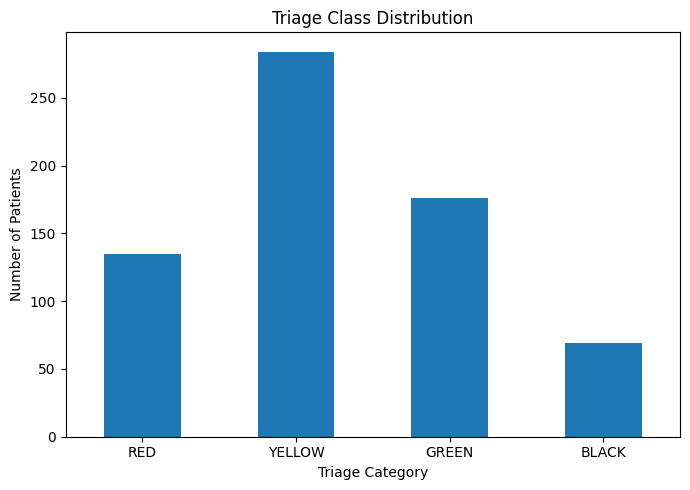

In [ ]:
# ============================================
# VISUALIZATION 1 - CLASS DISTRIBUTION
# ============================================

plt.figure(figsize=(7, 5))

train["start_category"].value_counts().reindex(
    ["RED", "YELLOW", "GREEN", "BLACK"]
).plot(kind="bar")

plt.title("Triage Class Distribution")
plt.xlabel("Triage Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

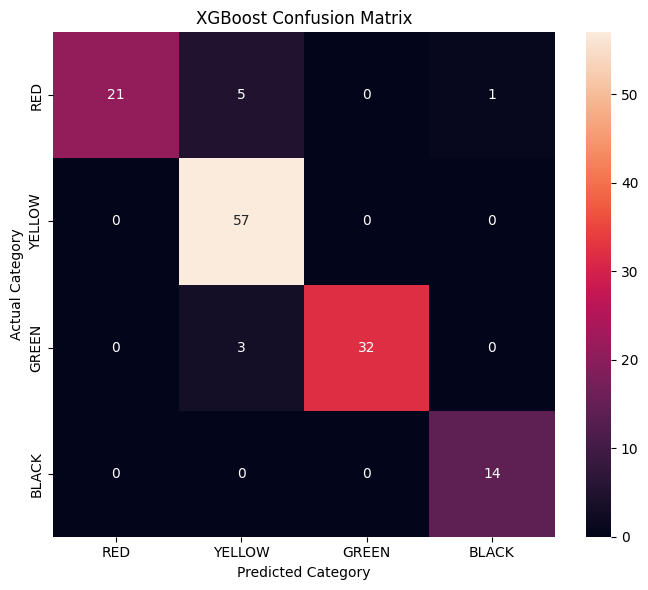

In [ ]:
# ============================================
# VISUALIZATION 2 - CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_valid,
    xgb_pred,
    labels=["RED", "YELLOW", "GREEN", "BLACK"]
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["RED", "YELLOW", "GREEN", "BLACK"],
    yticklabels=["RED", "YELLOW", "GREEN", "BLACK"]
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.tight_layout()
plt.show()

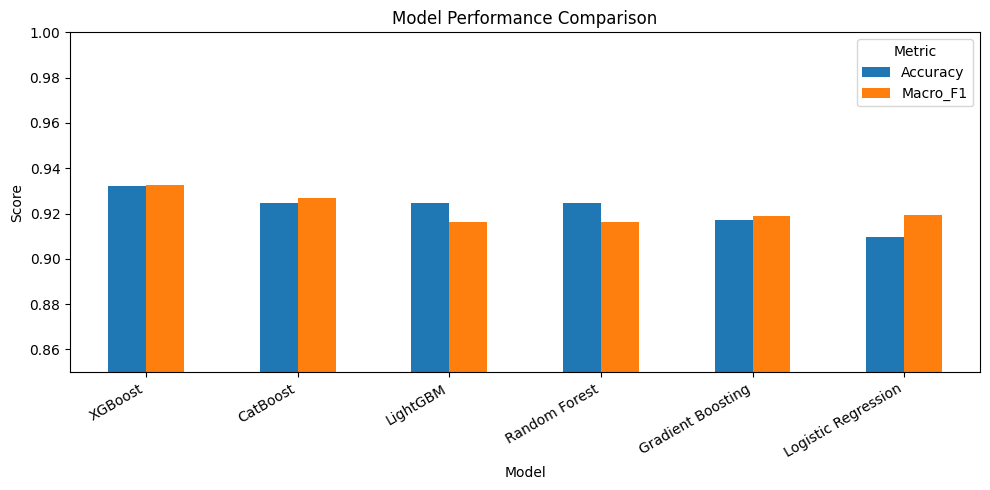

In [ ]:
# ============================================
# VISUALIZATION 3 - MODEL COMPARISON
# ============================================

model_results = pd.DataFrame({
    "Model": [
        "XGBoost",
        "CatBoost",
        "LightGBM",
        "Random Forest",
        "Gradient Boosting",
        "Logistic Regression"
    ],
    "Accuracy": [
        0.9323,
        0.9248,
        0.9248,
        0.9248,
        0.9173,
        0.9098
    ],
    "Macro_F1": [
        0.9325,
        0.9268,
        0.9161,
        0.9161,
        0.9188,
        0.9195
    ]
})

plot_data = model_results.set_index("Model")

plot_data.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0.85, 1.0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

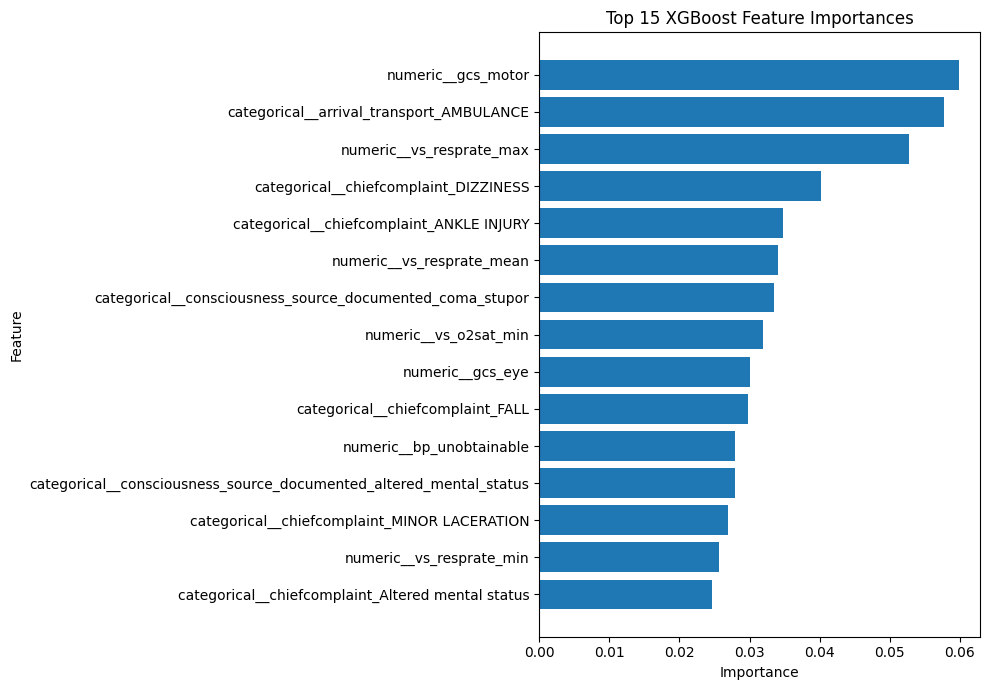

In [ ]:
# ============================================
# VISUALIZATION 4 - XGBOOST FEATURE IMPORTANCE
# ============================================

xgb_classifier = final_model.named_steps["classifier"]
final_preprocessor = final_model.named_steps["preprocessor"]

feature_names = final_preprocessor.get_feature_names_out()

importance = xgb_classifier.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(
    "Importance",
    ascending=False
).head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"][::-1],
    feature_importance["Importance"][::-1]
)

plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# FINAL SUBMISSION CSV
# ============================================

TEAM_ID = "MM2626"

filename = f"{TEAM_ID}_MM26ML03.csv"

# Make sure columns are in the exact required order
final_submission = submission[
    [
        "subject_id",
        "predicted_triage",
        "RED_probability",
        "YELLOW_probability",
        "GREEN_probability",
        "BLACK_probability"
    ]
].copy()

# Rename columns to the required submission format
final_submission.columns = [
    "Patient ID",
    "Predicted Triage",
    "RED Probability",
    "YELLOW Probability",
    "GREEN Probability",
    "BLACK Probability"
]

# Save CSV
final_submission.to_csv(filename, index=False)

print("========================================")
print("FINAL CSV CREATED")
print("========================================")
print("Filename:", filename)
print("Rows:", len(final_submission))
print("Columns:", list(final_submission.columns))

display(final_submission.head(10))

FINAL CSV CREATED
Filename: MM2626_MM26ML03.csv
Rows: 112
Columns: ['Patient ID', 'Predicted Triage', 'RED Probability', 'YELLOW Probability', 'GREEN Probability', 'BLACK Probability']


,Patient ID,Predicted Triage,RED Probability,YELLOW Probability,GREEN Probability,BLACK Probability
0,90000431,BLACK,0.007272,0.000998,0.000460,0.991270
1,90000438,BLACK,0.001397,0.000234,0.000313,0.998056
2,90000445,BLACK,0.021225,0.002017,0.000638,0.976121
3,90000457,BLACK,0.006579,0.000334,0.000216,0.992872
4,90000460,BLACK,0.005705,0.000471,0.000222,0.993602
5,90000461,BLACK,0.001256,0.000294,0.000265,0.998184
6,90000481,BLACK,0.001637,0.000251,0.001102,0.997010
7,90000489,BLACK,0.001512,0.000268,0.000349,0.997872
8,90000501,BLACK,0.001631,0.000209,0.000405,0.997755
9,90000502,BLACK,0.002330,0.000184,0.000159,0.997326


In [ ]:
from google.colab import files

files.download(filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Get model probabilities
manual_probabilities = final_model.predict_proba(manual_df)[0]

# Class order
CLASS_NAMES = ["RED", "YELLOW", "GREEN", "BLACK"]

# Cost-sensitive decision
manual_expected_cost = manual_probabilities @ COST_MATRIX

manual_prediction_index = np.argmin(manual_expected_cost)
manual_prediction = CLASS_NAMES[manual_prediction_index]

print("================================")
print("        TRIAGE RESULT")
print("================================")

print(f"\nTriage Category: {manual_prediction}")

print("\nClass Probabilities:")
for cls, prob in zip(CLASS_NAMES, manual_probabilities):
    print(f"{cls:8}: {prob:.4f}")

print("\nExpected Costs:")
for cls, cost in zip(CLASS_NAMES, manual_expected_cost):
    print(f"{cls:8}: {cost:.4f}")

        TRIAGE RESULT

Triage Category: BLACK

Class Probabilities:
RED     : 0.2234
YELLOW  : 0.0977
GREEN   : 0.0041
BLACK   : 0.6747

Expected Costs:
RED     : 1.5490
YELLOW  : 2.4708
GREEN   : 3.8770
BLACK   : 1.3167


In [ ]:
# ============================================
# MANUAL PATIENT TRIAGE TEST
# ============================================

classes = np.array(["RED", "YELLOW", "GREEN", "BLACK"])

manual_df = pd.DataFrame([patient])

# Make sure columns are in exactly the same order as training features
manual_df = manual_df[X.columns]

# Get model probabilities
manual_probabilities = final_model.predict_proba(manual_df)[0]

# Cost-sensitive decision
manual_expected_cost = manual_probabilities @ COST_MATRIX

manual_prediction_index = np.argmin(manual_expected_cost)
manual_prediction = classes[manual_prediction_index]

print("================================")
print("     TRIAGE RESULT")
print("================================")

print(f"\nTriage Category: {manual_prediction}")

print("\nClass Probabilities:")
for cls, prob in zip(classes, manual_probabilities):
    print(f"{cls:8}: {prob:.4f}")

print("\nExpected Costs:")
for cls, cost in zip(classes, manual_expected_cost):
    print(f"{cls:8}: {cost:.4f}")

     TRIAGE RESULT

Triage Category: YELLOW

Class Probabilities:
RED     : 0.0238
YELLOW  : 0.8332
GREEN   : 0.1359
BLACK   : 0.0070

Expected Costs:
RED     : 1.8164
YELLOW  : 0.2691
GREEN   : 2.7522
BLACK   : 1.9216
